In [52]:
# load results/imported.csv 
import pandas as pd

df = pd.read_csv('/Users/davisbrown/adaptive_evals/results/imported.csv')
incorrect_accuracy_adaptive = df['adaptive_incorrect_count'] / df['passed_judge_count']
incorrect_accuracy_re_eval = df['re_eval_incorrect_count'] / df['passed_judge_count']

df['incorrect_accuracy_adaptive'] = 1 - (df['adaptive_incorrect_count'] / df['passed_judge_count'])
df['transfer_accuracy'] = 1 - (df['re_eval_incorrect_count'] / df['passed_judge_count'])
df['transfer_error_rate'] = df['re_eval_incorrect_count'] / df['passed_judge_count']
df

# remove all columns except for eval_model_name, re_eval_model_name, incorrect_accuracy_adaptive, incorrect_accuracy_re_eval
df = df.drop(columns=['initial_log_path', 'adaptive_log_path', 're_eval_log_path', 'similarity_threshold', 'score_threshold', 'use_embeddings', 're_eval_accuracy_judged', 're_eval_scorer_name', "use_cot",  "filter_incorrect", "n_datapoints"])

df_4o_eval = df[df['eval_model_name'] == "openai/gpt-4o-mini"]
df_4o_eval

,eval_model_name,generator_model_name,re_eval_model_name,adaptive_accuracy,adaptive_accuracy_judged,adaptive_scorer_name,re_eval_accuracy,judge_model_name,max_attempts,passed_judge_count,adaptive_incorrect_count,re_eval_incorrect_count,incorrect_accuracy_adaptive,transfer_accuracy,transfer_error_rate
6,openai/gpt-4o-mini,openai/gpt-4o,openai/gpt-4o,1.0,NaN,adaptive_truthfulqa_scorer,0.571429,anthropic/claude-3-5-sonnet-latest,10,42,42,18,0.0,0.571429,0.428571
7,openai/gpt-4o-mini,openai/gpt-4o,openai/gpt-4o-mini,1.0,NaN,adaptive_truthfulqa_scorer,0.238095,anthropic/claude-3-5-sonnet-latest,10,42,42,32,0.0,0.238095,0.761905
8,openai/gpt-4o-mini,openai/gpt-4o,openai/o1-mini,1.0,NaN,adaptive_truthfulqa_scorer,0.309524,anthropic/claude-3-5-sonnet-latest,10,42,42,29,0.0,0.309524,0.690476
9,openai/gpt-4o-mini,openai/gpt-4o,together/deepseek-ai/DeepSeek-V3,1.0,NaN,adaptive_truthfulqa_scorer,0.428571,anthropic/claude-3-5-sonnet-latest,10,42,42,24,0.0,0.428571,0.571429
10,openai/gpt-4o-mini,openai/gpt-4o,together/meta-llama/Llama-3.3-70B-Instruct-Turbo,1.0,NaN,adaptive_truthfulqa_scorer,0.428571,anthropic/claude-3-5-sonnet-latest,10,42,42,24,0.0,0.428571,0.571429
11,openai/gpt-4o-mini,openai/gpt-4o,anthropic/claude-3-5-sonnet-latest,1.0,NaN,adaptive_truthfulqa_scorer,0.523810,anthropic/claude-3-5-sonnet-latest,10,42,42,20,0.0,0.523810,0.476190


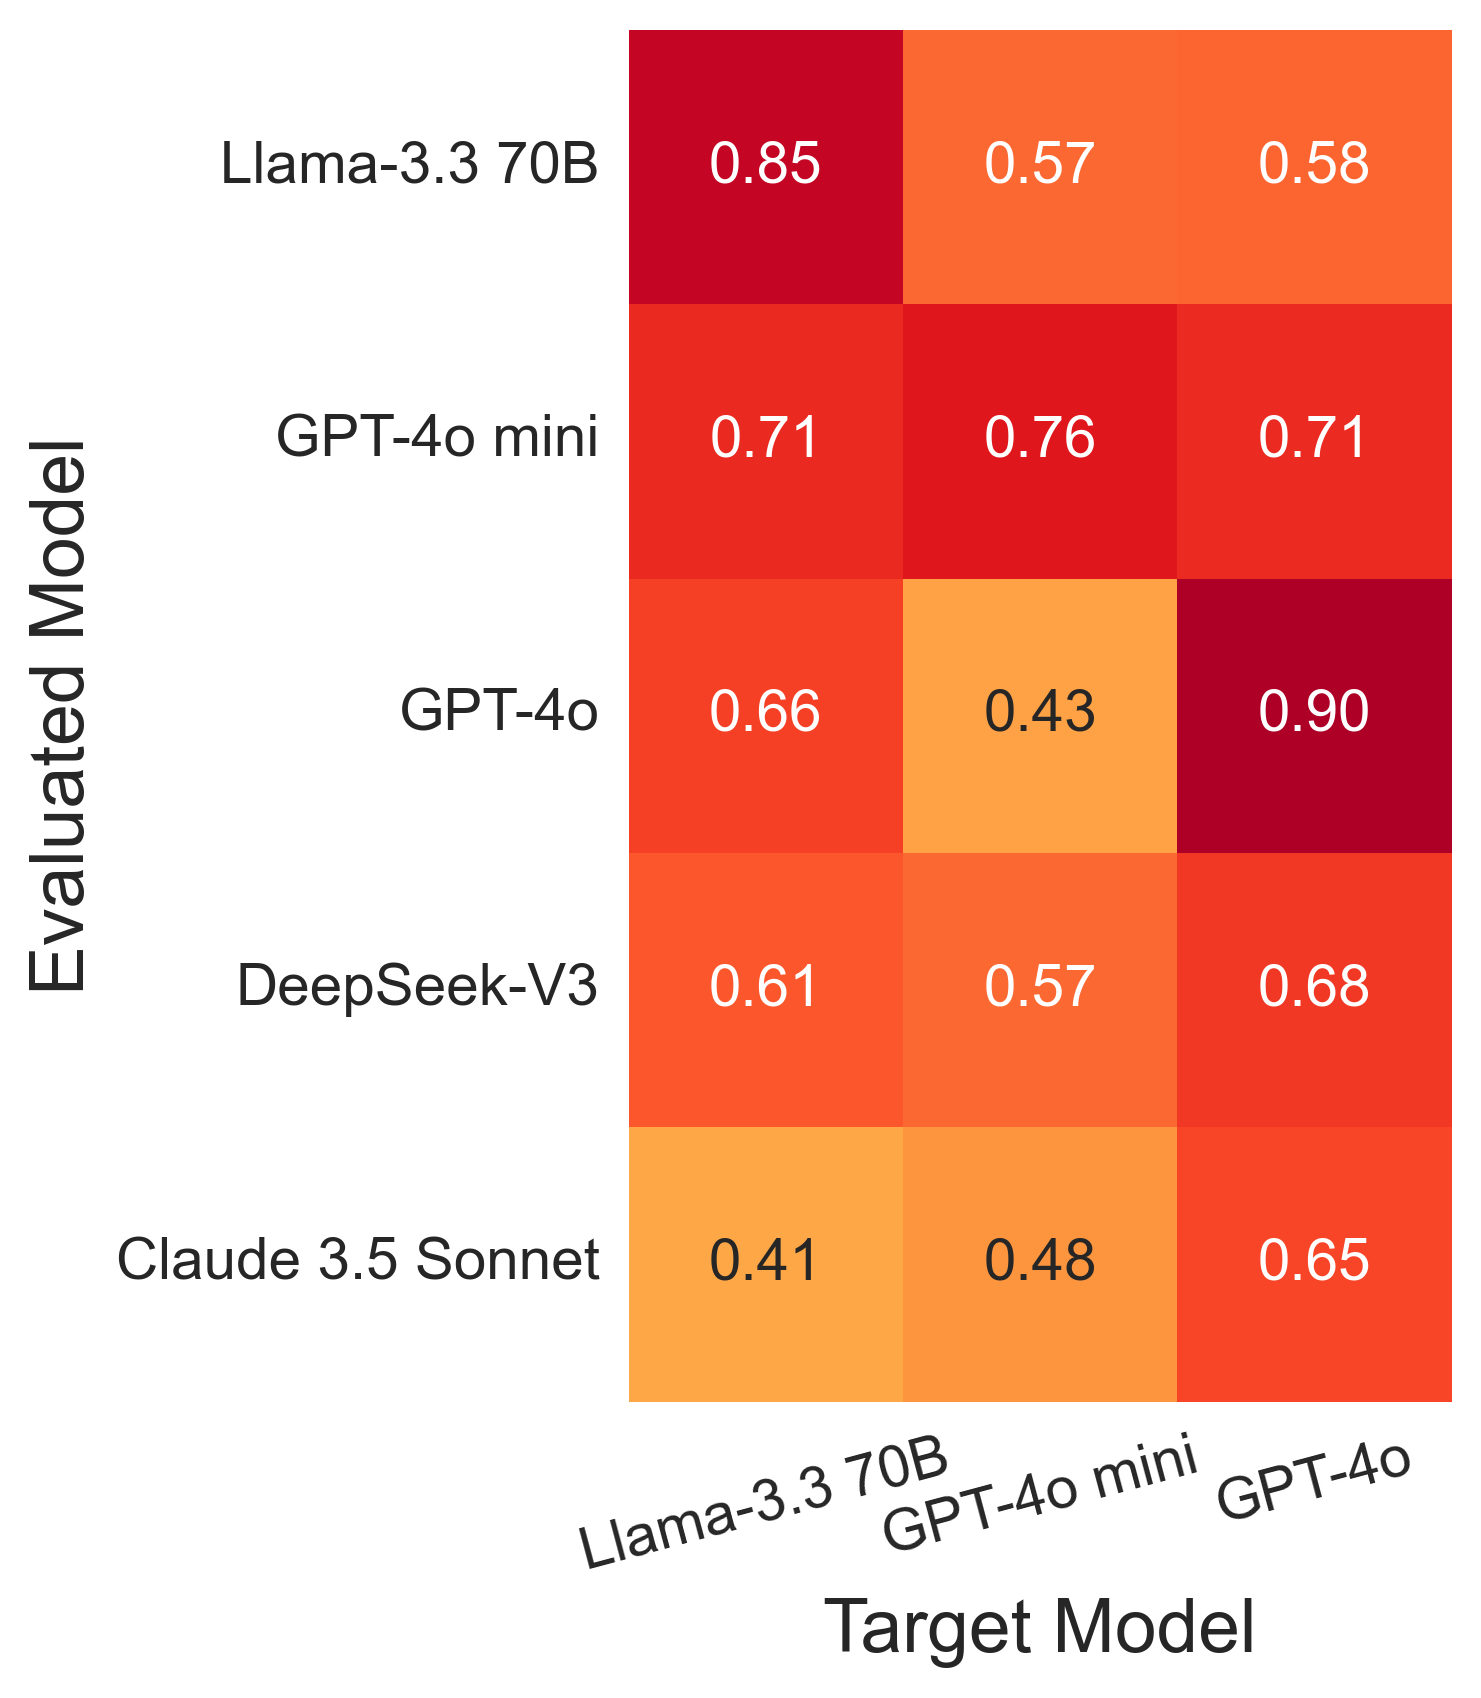

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

df_for_plot = df.copy()

# Extract final part of model names
df_for_plot['eval_model_name'] = df_for_plot['eval_model_name'].str.split('/').str[-1].str.replace('Llama-3.3-70B-Instruct-Turbo', 'Llama-3.3 70B').replace('claude-3-5-sonnet-latest', 'Claude 3.5 Sonnet').replace('gpt-4o-mini', 'GPT-4o mini').replace('gpt-4o', 'GPT-4o')
df_for_plot['re_eval_model_name'] = df_for_plot['re_eval_model_name'].str.split('/').str[-1].str.replace('Llama-3.3-70B-Instruct-Turbo', 'Llama-3.3 70B').replace('claude-3-5-sonnet-latest', 'Claude 3.5 Sonnet').replace('gpt-4o-mini', 'GPT-4o mini').replace('gpt-4o', 'GPT-4o')

# Define model order
eval_model_order = ['Llama-3.3 70B', 'GPT-4o mini', 'GPT-4o']
# re_eval_model_order = ['Llama-3.3-70B', 'GPT-4o-mini', 'GPT-4o', 'o1-mini', 'DeepSeek-V3', 'Claude-3.5-Sonnet']
re_eval_model_order = ['Llama-3.3 70B', 'GPT-4o mini', 'GPT-4o', 'DeepSeek-V3', 'Claude 3.5 Sonnet']

# Pivot the data for heatmap format - flipped axes
heatmap_data = df_for_plot.pivot(
    index='re_eval_model_name',
    columns='eval_model_name', 
    values='transfer_error_rate'
)

# Reorder the index and columns
heatmap_data = heatmap_data.reindex(index=re_eval_model_order)
heatmap_data = heatmap_data.reindex(columns=eval_model_order)

# Set style for paper-quality plots
sns.set_style("white")
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 24,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# Create figure with higher DPI for paper quality
plt.figure(figsize=(6, 6), dpi=300)

# Create heatmap with enhanced styling
sns.heatmap(
    heatmap_data,
    annot=True,  # Show values in cells
    fmt='.2f',   # Format as 2 decimal places
    cmap='YlOrRd',  # Yellow-Orange-Red colormap
    cbar=False,  # Remove colorbar
    # cbar_kws={
    #     # 'label': 'Error rate (better transfer from\n' + r'target $\longrightarrow$ evaluated model)',
    #     # 'label': r'Error rate / better transfer $\longrightarrow$',
    #     # 'label': r'Target $\longrightarrow$ evaluated transfer',
    #     'shrink': 0.8,  # Make colorbar smaller
    #     'aspect': 8     # Make colorbar thinner
    # },
    square=True,
    vmin=0,
    vmax=1,
    annot_kws={'size': 14}  # Larger font for cell values
)

# Customize labels and title - flipped labels
plt.xlabel('Target Model', fontsize=18)
plt.ylabel('Evaluated Model', fontsize=18)

# Adjust x-axis labels for readability
plt.xticks(rotation=15, ha='center')
plt.yticks(rotation=0)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save as PDF for paper
plt.savefig('transfer_accuracy.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


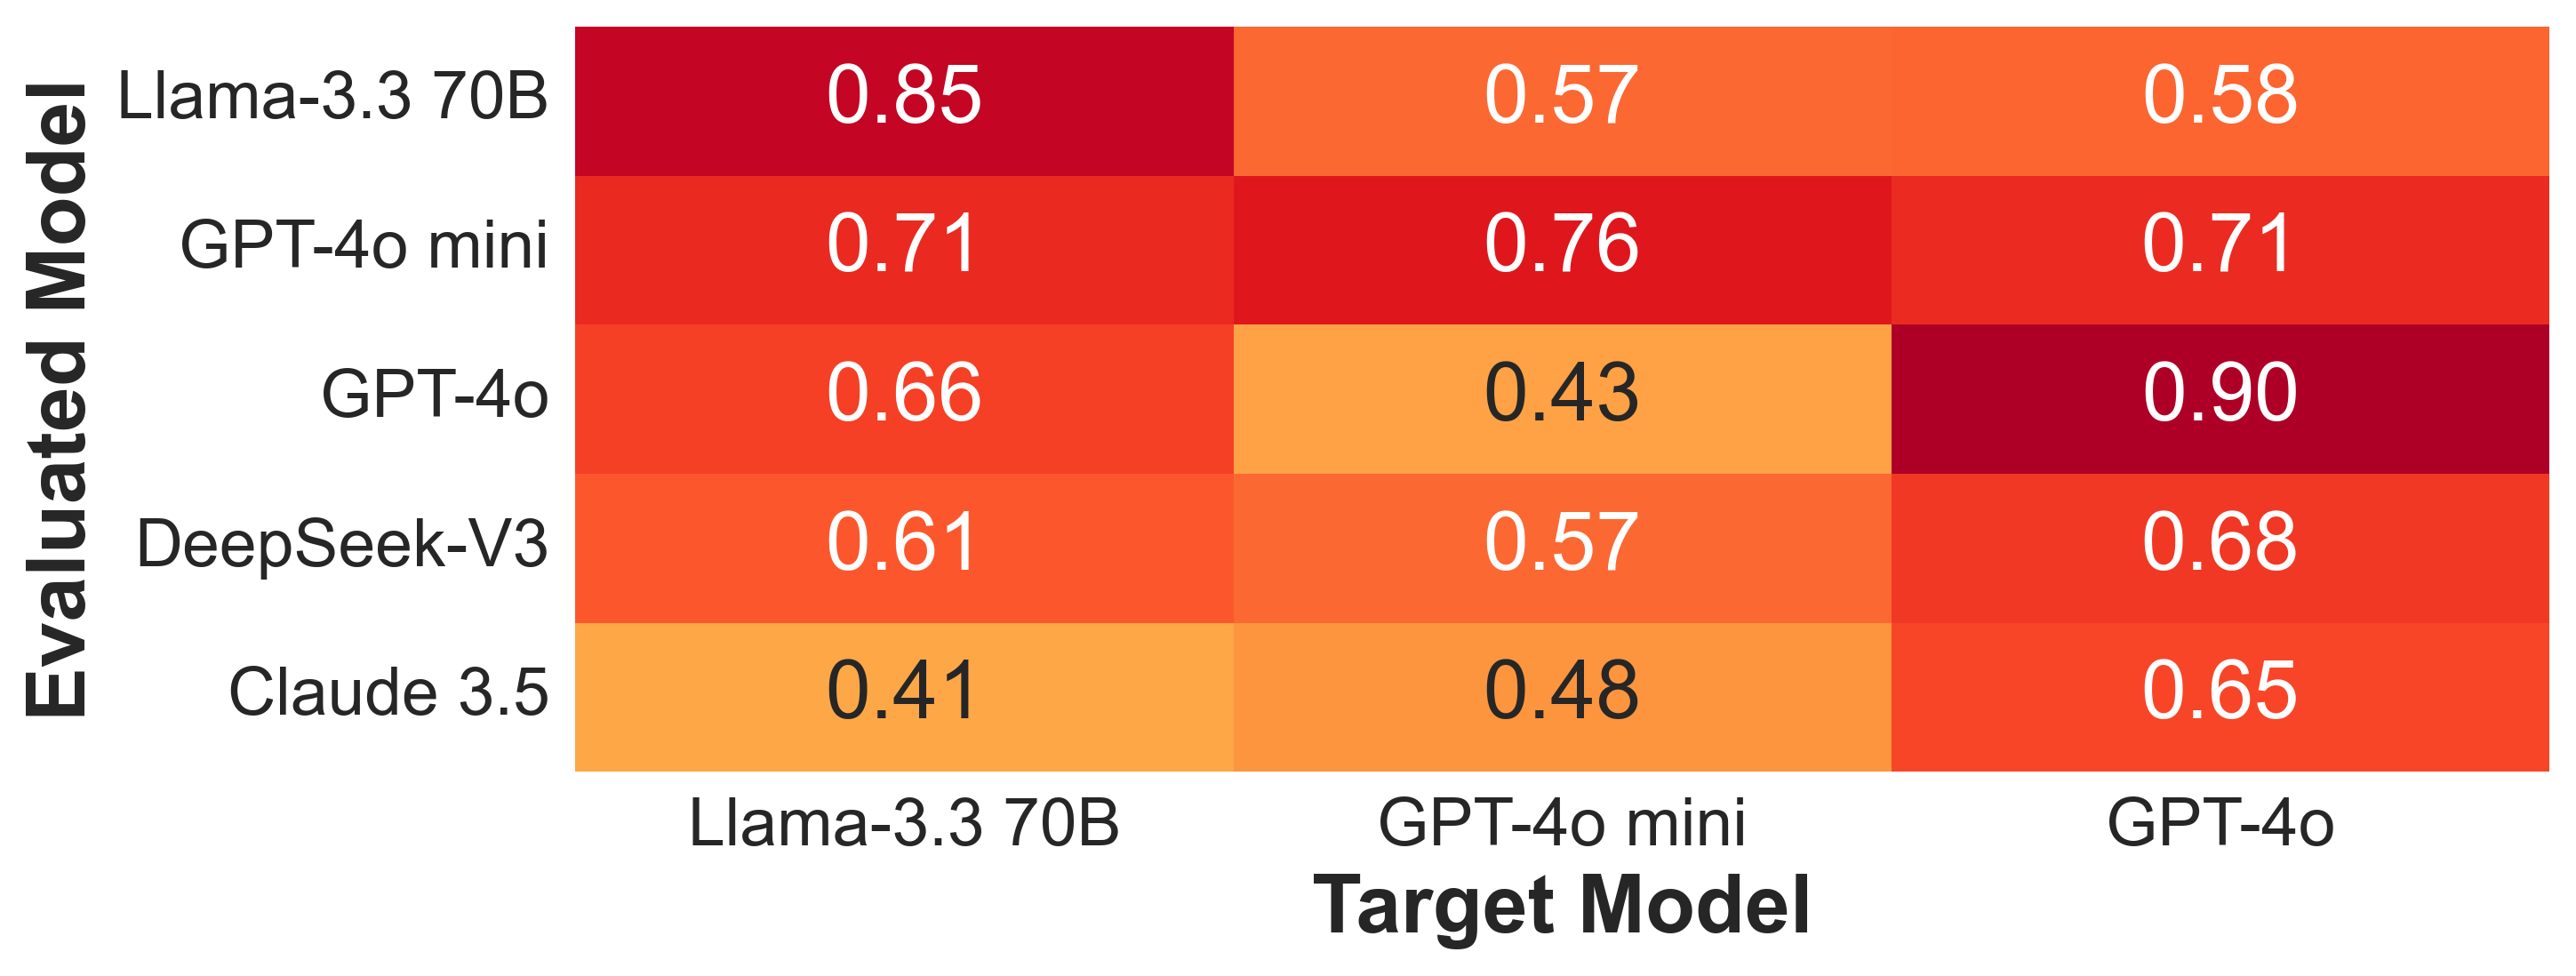

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

df_for_plot = df.copy()

# Extract final part of model names
df_for_plot['eval_model_name'] = (
    df_for_plot['eval_model_name']
    .str.split('/')
    .str[-1]
    .str.replace('Llama-3.3-70B-Instruct-Turbo', 'Llama-3.3 70B')
    .replace('claude-3-5-sonnet-latest', 'Claude 3.5')
    .replace('gpt-4o-mini', 'GPT-4o mini')
    .replace('gpt-4o', 'GPT-4o')
)
df_for_plot['re_eval_model_name'] = (
    df_for_plot['re_eval_model_name']
    .str.split('/')
    .str[-1]
    .str.replace('Llama-3.3-70B-Instruct-Turbo', 'Llama-3.3 70B')
    .replace('claude-3-5-sonnet-latest', 'Claude 3.5')
    .replace('gpt-4o-mini', 'GPT-4o mini')
    .replace('gpt-4o', 'GPT-4o')
)

# Define model order
eval_model_order = ['Llama-3.3 70B', 'GPT-4o mini', 'GPT-4o']
re_eval_model_order = ['Llama-3.3 70B', 'GPT-4o mini', 'GPT-4o', 'DeepSeek-V3', 'Claude 3.5']

# Pivot the data for heatmap format - flipped axes
heatmap_data = df_for_plot.pivot(
    index='re_eval_model_name',
    columns='eval_model_name',
    values='transfer_error_rate'
)

# Reorder the index and columns
heatmap_data = heatmap_data.reindex(index=re_eval_model_order)
heatmap_data = heatmap_data.reindex(columns=eval_model_order)

# Set style for paper-quality plots
sns.set_style("white")
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18
})

# Make the figure wide enough to avoid rotating x-axis labels
plt.figure(figsize=(10, 4), dpi=300)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=False,
    square=False,  # Allow rectangular heatmap cells
    vmin=0,
    vmax=1,
    annot_kws={'size': 22}
)

plt.xlabel('Target Model', fontsize=22, fontweight='bold')
plt.ylabel('Evaluated Model', fontsize=22, fontweight='bold')

# Keep ticks unrotated now that there's enough width
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('transfer_accuracy.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

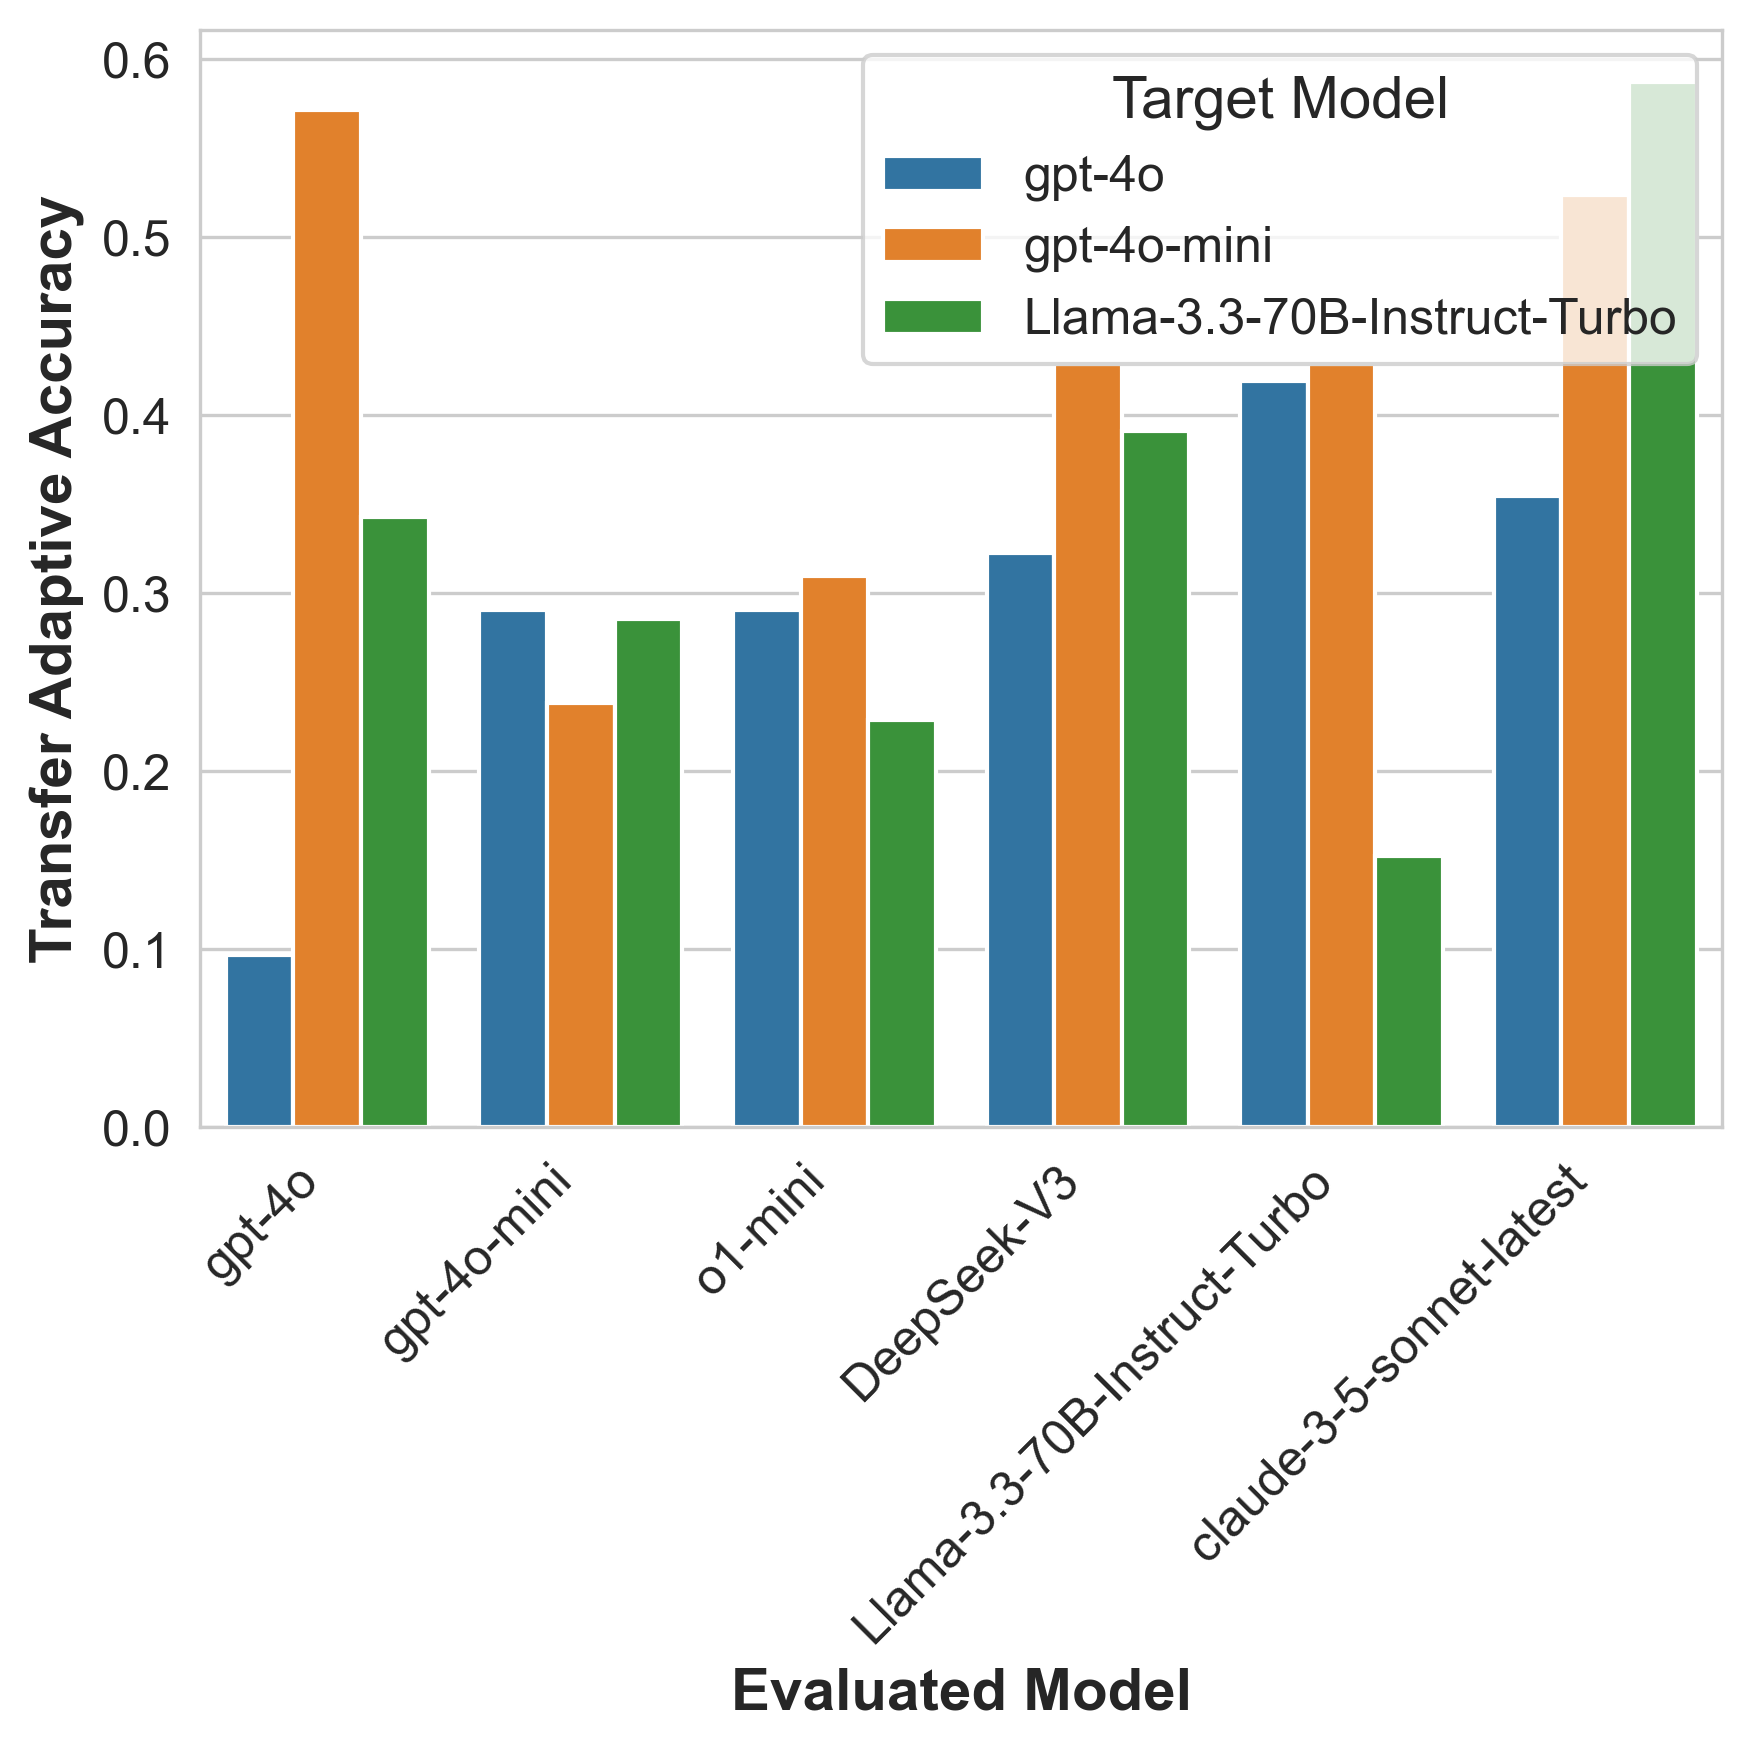

In [49]:
# plot the accuracy of each re_eval_model_name for each eval_model_name in a bar chart, colored by the eval_model_name
# use seaborn to plot the bar chart
import seaborn as sns
import matplotlib.pyplot as plt

df_for_plot = df.copy()

# Extract final part of model names
df_for_plot['eval_model_name'] = df_for_plot['eval_model_name'].str.split('/').str[-1]
df_for_plot['re_eval_model_name'] = df_for_plot['re_eval_model_name'].str.split('/').str[-1]

# Set style for paper-quality plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14
})

# Create figure with higher DPI for paper quality
plt.figure(figsize=(6, 6), dpi=300)  # Increased width to accommodate legend

# Create plot with enhanced styling
sns.barplot(x='re_eval_model_name', y='transfer_accuracy', data=df_for_plot, hue='eval_model_name')

# Customize labels and title
plt.xlabel('Evaluated Model', fontweight='bold')
plt.ylabel('Transfer Adaptive Accuracy', fontweight='bold')

# Adjust x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Enhance legend - moved inside plot area
plt.legend(title='Target Model', title_fontsize=14, loc='upper right')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save as PDF for paper
plt.savefig('transfer_accuracy_bar.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
